In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:18pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = "retina"
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [ ]:
# 1.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

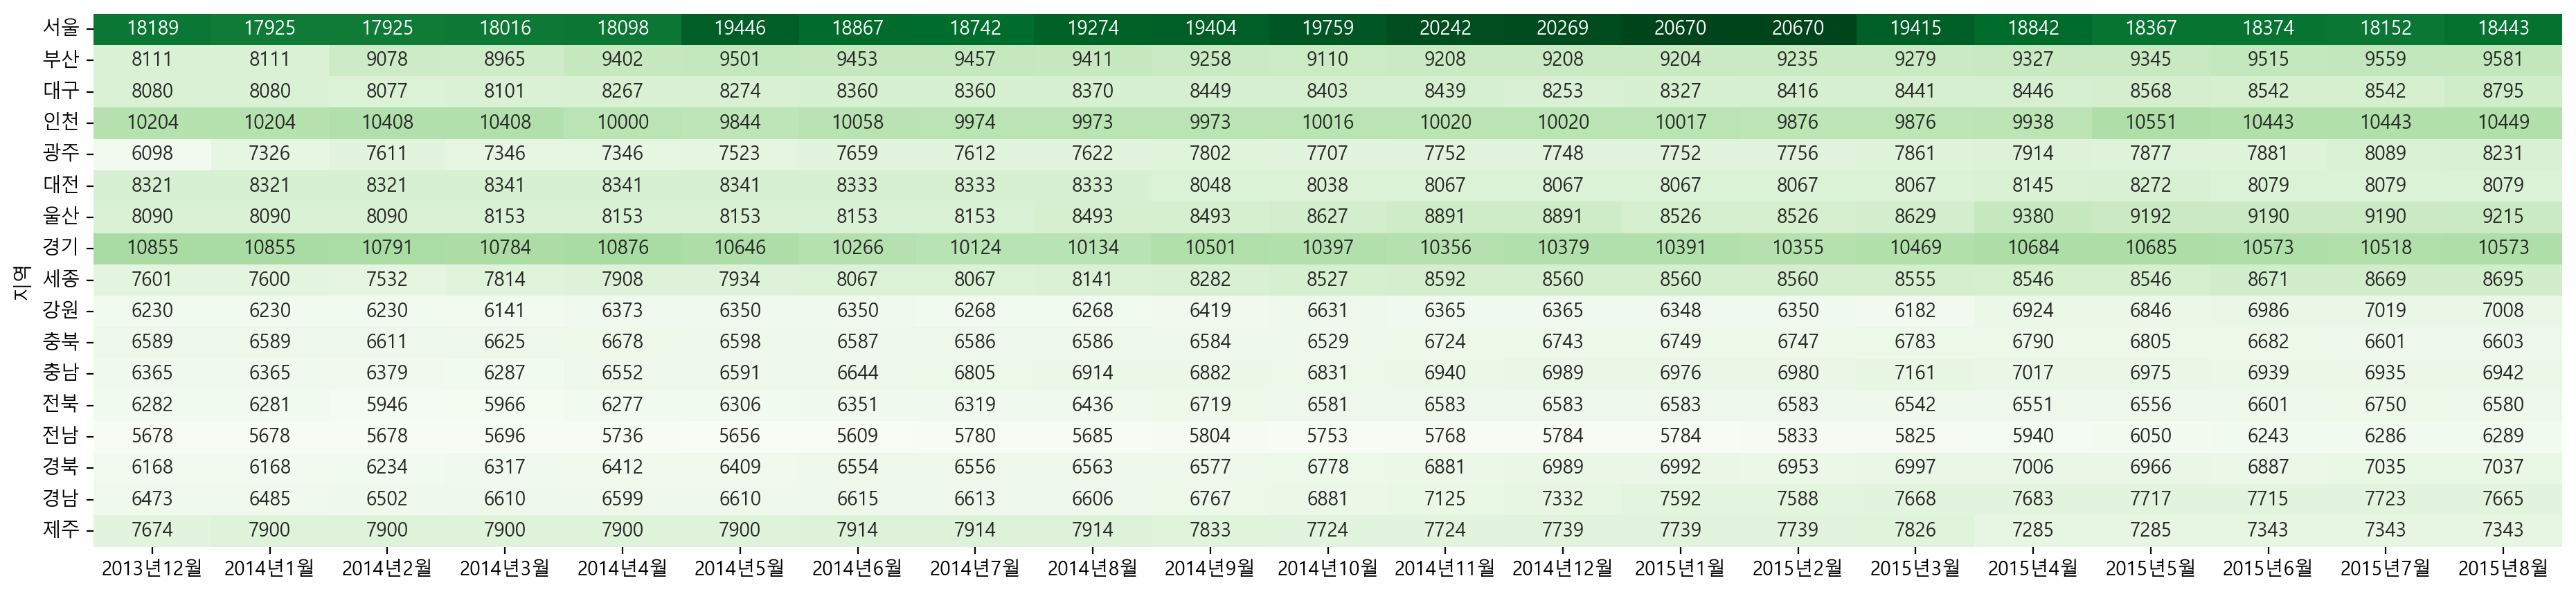

In [45]:
df_first = pd.read_csv(r'C:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.info()
df_first.set_index('지역', inplace=True)

plt.figure(figsize=(23,5))
sns.heatmap(df_first, annot=True, fmt='.0f', cmap='Greens', cbar=False)
plt.show()

In [ ]:
# 2.

In [38]:
df_last = pd.read_csv(r'C:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                     encoding='cp949')

df_last['분양가격(제곱미터당 천원)'] = pd.to_numeric(
    df_last['분양가격(제곱미터당 천원)'].astype(str).str.replace(',', ''), errors='coerce')
df_last['평당분양가격'] = df_last['분양가격(제곱미터당 천원)'] *3.3
df_last.drop(['분양가격(제곱미터당 천원)'], axis=1, inplace=True)
df_last

,지역명,규모구분,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,19400.7
...,...,...,...,...,...
10875,제주,모든면적,2026,5,14760.9
10876,제주,전용면적 60제곱미터이하,2026,5,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,14800.5
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN


In [ ]:
# 3.

In [42]:
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400000,20315.680000,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800000
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535000,21753.435000,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615000,21864.095000,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565000
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965000,23202.245000,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295000
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865000,28286.830000,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010000,29781.015000,11628.100000,12837.600000,14982.990000,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655000,29380.450000,12578.060000,14191.953061,15774.330000,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2022,11644.215000,16621.550,12455.685000,12018.050000,15095.885106,16821.915000,14113.880000,18166.835593,29128.531034,11309.971698,17903.751724,17341.830000,10635.508475,10003.070000,18953.825000,11730.345000,10033.540000
2023,13409.385000,20175.210,13283.182759,13025.320000,17957.852830,17656.747059,17917.288889,20470.850847,33230.560000,12278.200000,18832.093220,16150.695000,11846.682692,10966.024528,24095.901923,12580.590000,11103.950000


In [ ]:
# 4.

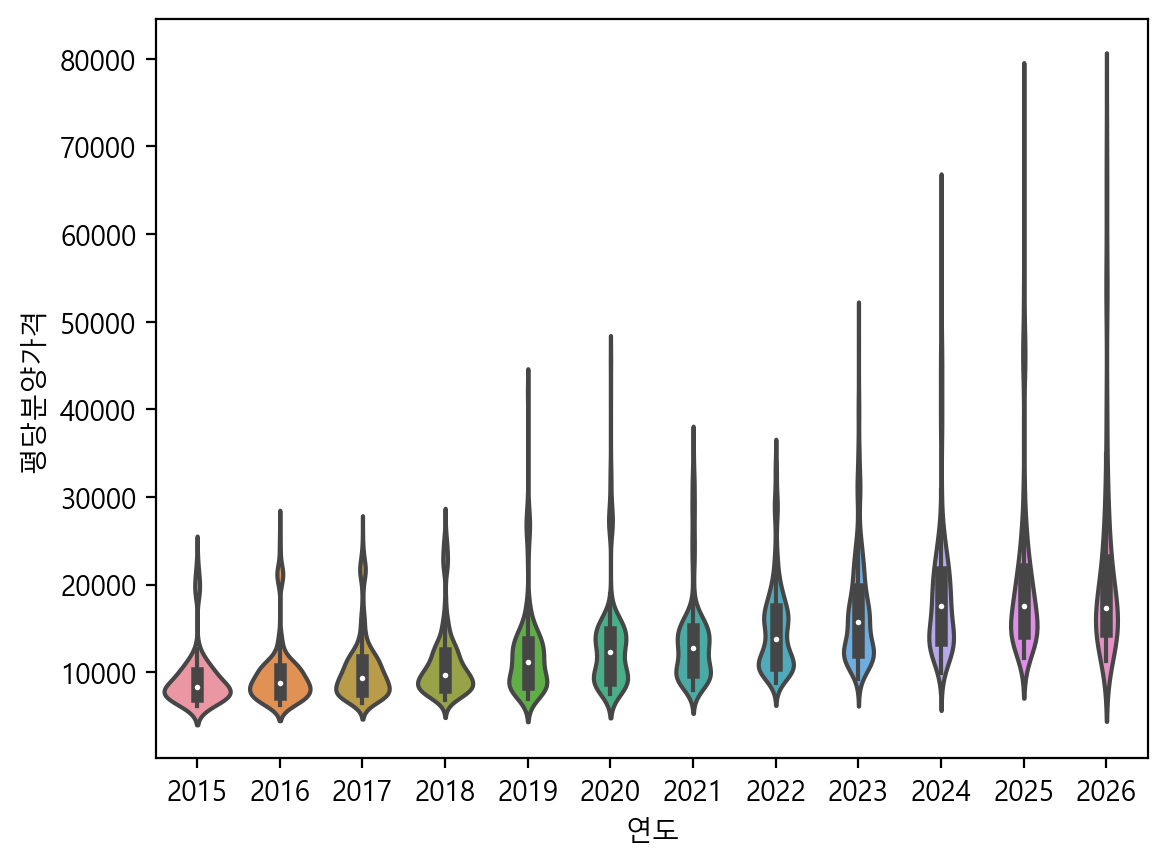

In [53]:
v = sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

In [ ]:
# 5.

In [70]:
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


In [71]:
new_first = pd.melt(df_first, id_vars='지역',var_name='연도월',value_vars='평당분양가격')
new_first.head(1)

KeyError: '지역'